# DTSA 5510 Final Project
For my final project, I choose to analyze and model home sales prices in Ames, Iowa. I received this dataset from Kaggle.com and the link is here https://www.kaggle.com/competitions/home-data-for-ml-course/overview.
Here is some more information about the dataset from Kaggle: 
Ask a home buyer to describe their dream house, and they probably won't begin with the height of the basement ceiling or the proximity to an east-west railroad. But this dataset proves that much more influences price negotiations than the number of bedrooms or a white-picket fence. There are 79 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa. Here the key groups of the variables in the dataset:
Key Groups:

Identifiers: Id

<b>Structural Attributes</b>: MSSubClass, OverallQual/Cond, YearBuilt, YearRemodAdd

<b>Lot & Land Features</b>: LotFrontage, LotArea, LotShape, LandContour, LandSlope

<b>Exterior & Basement</b>: Exterior1st/2nd, MasVnrType/Area, BsmtQual/Cond/Exposure, TotalBsmtSF

<b>Living Areas & Rooms</b>: 1stFlrSF, 2ndFlrSF, GrLivArea, bathroom/bedroom counts

<b>Garage & Miscellaneous</b>: GarageType/Area/Cars/Cond, PoolQC, Fence, MiscFeature/Val

<b>Sale Info</b>: MoSold, YrSold, SaleType, SaleCondition, and the target SalePrice



### ML problem at hand
We want to use the training data from Kaggle to train an unsupervised ML model so that it can predict home sale prices given a test dataset. Both the train and test datasets were provided from Kaggle at the link above.

## EDA

#Import libraries

In [2]:
import pandas as pd
import numpy as np

### Load downloaded data that can be found in github repo

In [27]:
url = 'https://github.com/dnmorgan/MSDS/blob/DTSA5009/train.csv?raw=true'
df = pd.read_csv(url,index_col=0)
print(df.head(5))


    MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                    
1           60       RL         65.0     8450   Pave   NaN      Reg   
2           20       RL         80.0     9600   Pave   NaN      Reg   
3           60       RL         68.0    11250   Pave   NaN      IR1   
4           70       RL         60.0     9550   Pave   NaN      IR1   
5           60       RL         84.0    14260   Pave   NaN      IR1   

   LandContour Utilities LotConfig  ... PoolArea PoolQC Fence MiscFeature  \
Id                                  ...                                     
1          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
2          Lvl    AllPub       FR2  ...        0    NaN   NaN         NaN   
3          Lvl    AllPub    Inside  ...        0    NaN   NaN         NaN   
4          Lvl    AllPub    Corner  ...        0    NaN   NaN         NaN   
5          Lvl    AllPub       FR2  ... 

In [28]:
# 1. Dataset Components
print("=== Dataset Components ===")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\nData types breakdown:")
print(df.dtypes.value_counts())

print("\nSample of columns by type:")
print("Numeric:", df.select_dtypes(include=[np.number]).columns.tolist()[:10], "...")
print("Categorical:", df.select_dtypes(include=['object']).columns.tolist()[:10], "...")


=== Dataset Components ===
Number of rows: 1460
Number of columns: 80

Data types breakdown:
object     43
int64      34
float64     3
Name: count, dtype: int64

Sample of columns by type:
Numeric: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2'] ...
Categorical: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...


### Missing Values Summary

In [29]:
print("\n=== Missing Values Summary ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)
print(missing_summary.head(20))


=== Missing Values Summary ===
              missing_count  missing_pct
PoolQC                 1453        99.52
MiscFeature            1406        96.30
Alley                  1369        93.77
Fence                  1179        80.75
MasVnrType              872        59.73
FireplaceQu             690        47.26
LotFrontage             259        17.74
GarageYrBlt              81         5.55
GarageCond               81         5.55
GarageType               81         5.55
GarageFinish             81         5.55
GarageQual               81         5.55
BsmtExposure             38         2.60
BsmtFinType2             38         2.60
BsmtCond                 37         2.53
BsmtQual                 37         2.53
BsmtFinType1             37         2.53
MasVnrArea                8         0.55
Electrical                1         0.07
MSSubClass                0         0.00


### Identify Potential Columns to Drop 

In [30]:
# e.g. drop columns with > 50% missing
drop_thresh = 50.0
to_drop = missing_summary[missing_summary['missing_pct'] > drop_thresh].index.tolist()
print(f"\nColumns with >{drop_thresh}% missing (to consider dropping):")
print(to_drop)


Columns with >50.0% missing (to consider dropping):
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


### Imputation Strategy

In [31]:
# Impute LotFrontage by median within each Neighborhood
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'] \
                                     .transform(lambda x: x.fillna(x.median()))

# Fill other categorical gaps with "None"
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('None')

print("\nAfter imputation, missing values remaining:")
print(df.isnull().sum().loc[lambda x: x > 0])



After imputation, missing values remaining:
MasVnrArea      8
GarageYrBlt    81
dtype: int64


### Look at Correlations

In [32]:
#Correlation with SalePrice
print("\n=== Top 10 Features Correlated with SalePrice ===")
numeric = df.select_dtypes(include=[np.number])
corr = numeric.corr()['SalePrice'].abs().sort_values(ascending=False).drop('SalePrice')
print(corr.head(10))


=== Top 10 Features Correlated with SalePrice ===
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


### Actually droping columns
Since none of the variables listed with over 50% missing are in the top ten features correlated with saleprice above, we
will now drop them

In [33]:
df = df.drop(columns=['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType'])

### Determining variables to transform

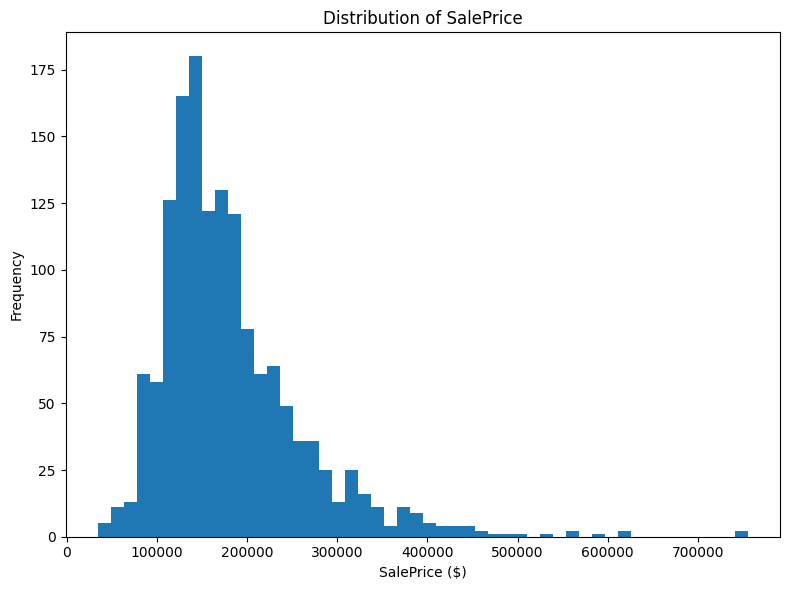

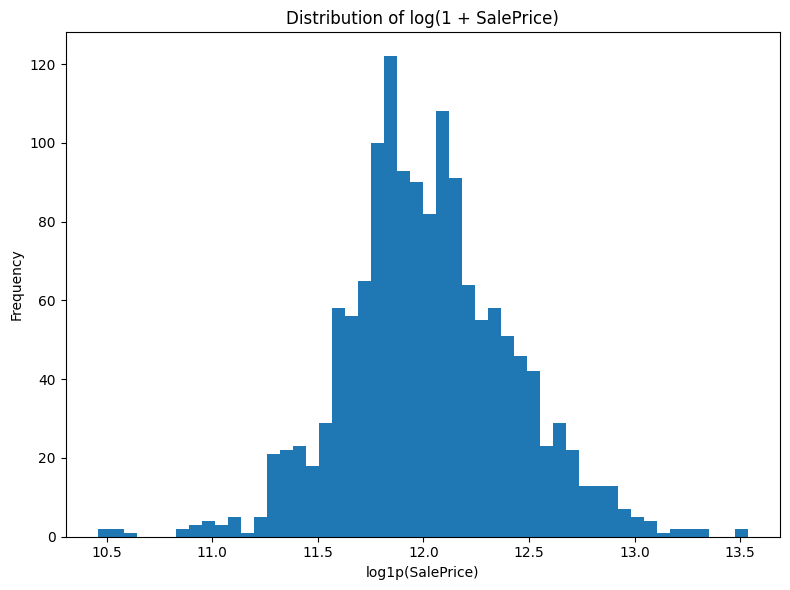

In [34]:
#!pip install matplotlib
import matplotlib.pyplot as plt
# Histogram of SalePrice
plt.figure(figsize=(8, 6))
plt.hist(df['SalePrice'], bins=50)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice ($)')
plt.ylabel('Frequency')
plt.tight_layout()

# Histogram of log1p(SalePrice)
plt.figure(figsize=(8, 6))
plt.hist(np.log1p(df['SalePrice']), bins=50)
plt.title('Distribution of log(1 + SalePrice)')
plt.xlabel('log1p(SalePrice)')
plt.ylabel('Frequency')
plt.tight_layout()

plt.show()


We see that SalePrice is highly right-skewed. Whereas Log1p(SalePrice) is nearly symmetric.

Given this information from the histogram, we will model the target on the log scale (y = log1p(SalePrice)) to stabilize variance and improve linear-model assumptions.

# Running the models

In [35]:
#load proper libraries and funcitons from 
#!pip install scikit-learn
#import sklearn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering

# Dimensionality Reduction with PCA

### More imputation is need that what was done in initial EDA. I am going to use sklearn's SimpleImputer to accomplish this. PCA computes covariances/variances so missing values break those calculations. Later on clustering measures distances and NaNs make distances undefined, so imputation is needed for this too.

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# identify numeric feature names
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('SalePrice')  # drop target

# build numeric pipeline using median imputation → scaling
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# a columnTransformer which is only numeric since PCA needs numbers
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, num_cols)
])

# full PCA pipeline here 
pca_pipeline = Pipeline([
    ('prep', preprocessor),
    ('pca',  PCA(n_components=0.95, random_state=42))
])

# Actual PCA happening here. Fit & transform
X_pca = pca_pipeline.fit_transform(df.drop(columns=['SalePrice']))

print(f"Original dims: {len(num_cols)}, PCA dims: {X_pca.shape[1]}")


Original dims: 36, PCA dims: 26


## K-means clustering

In [37]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# K-Means on the PCA space
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_KM'] = kmeans.fit_predict(X_pca)

# Hierarchical on the PCA space
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster_HC'] = hc.fit_predict(X_pca)

print("\nAverage SalePrice by K‑Means cluster:")
print(df.groupby('Cluster_KM')['SalePrice'].mean().sort_index())

print("\nAverage SalePrice by Hierarchical cluster:")
print(df.groupby('Cluster_HC')['SalePrice'].mean().sort_index())




Average SalePrice by K‑Means cluster:
Cluster_KM
0    129118.031250
1    222752.606742
2    155016.012346
3    259697.797909
4    120799.552448
Name: SalePrice, dtype: float64

Average SalePrice by Hierarchical cluster:
Cluster_HC
0    143357.127711
1    246070.477663
2    134995.382716
3    241435.956175
4    288138.571429
Name: SalePrice, dtype: float64


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Clustering discussion
There are five distinct tiers: K‑Means has effectively split the market into five price bands, from 'lowest-end' ~120k salesprice to 'premium' at ~260k salesprice.  There is granularity at the low end i.e. there are two separate “budget” segments Clusters 4 and 0 at \\$120 k vs \\$129 k. This suggests there may be subtle but consistent feature differences among the more affordable homes. There is even spacing in the middle, Clusters 2 (\\$155 k) and 1 (\\$223 k) carve out a clear mid‑ vs upper‑mid tier. During the hierarchical clustering three main segments were defined with a premium outlier. Hierarchical clustering has effectively carved the data into:

Budget (~$135–143 k),

Mid/high (~$241–246 k),

Premium (~$288 k).

A single “premium” spike: Cluster 4 ( $288 k) is distinctively above the rest—hierarchical sees those homes as their own group.

## Further clustering analysis
Plotting within‑cluster variance can help decide if 5 is really the best number of groups, or if 3–4 clusters capture the bulk of the structure.

In [38]:
print(df['Cluster_KM'].value_counts())
print(df.groupby('Cluster_KM')['SalePrice'].std())

Cluster_KM
4    429
1    356
2    324
3    287
0     64
Name: count, dtype: int64
Cluster_KM
0    30174.225562
1    64548.584908
2    33147.519244
3    93998.369795
4    32269.275763
Name: SalePrice, dtype: float64


Cluster 4 is the largest group (429 homes), followed by Clusters 1, 2, and 3, with Cluster 0 being very small. This tells us that the bulk of data lives in Clusters 4→1→2→3, and Cluster 0 is a relatively rare “segment” in the space. The standard deviations of SalePrice in each cluster show that clusters 0, 2, and 4 have low dispersion (\\$30 k–\\$33 k), meaning homes in those clusters tend to fall into a relatively tight price band.

# Load and run test dataset
### Assign unsupervised labels (PCA + Clusters) to the test set

In [39]:
# Load test dataset
test = pd.read_csv('/kaggle/input/home-data-for-ml-course/test.csv', index_col=0)

In [42]:
# Impute exactly as done on training dataset:
# - LotFrontage by Neighborhood median
# – Cat cols fill with 'None'
test_imputed = test.copy()
test_imputed['LotFrontage'] = (
    test_imputed.groupby('Neighborhood')['LotFrontage']
    .transform(lambda x: x.fillna(x.median()))
)
cat_cols = test_imputed.select_dtypes(include=['object']).columns
test_imputed[cat_cols] = test_imputed[cat_cols].fillna('None')

X_test_pca = pca_pipeline.transform(test_imputed)

# Cluster assignment (reuse your fitted KMeans/hierarchical)
test['Cluster_KM'] = kmeans.predict(X_test_pca)
test['Cluster_HC'] = hc.fit_predict(X_test_pca)  # or .labels_ if you prefer

# Summarize test‐set cluster sizes
print(test['Cluster_KM'].value_counts().sort_index())
print(test['Cluster_HC'].value_counts().sort_index())



Cluster_KM
0     56
1    322
2    333
3    295
4    453
Name: count, dtype: int64
Cluster_HC
0    862
1    273
2    259
3      2
4     63
Name: count, dtype: int64


### Comparing test and train outputs
Cluster_KM (test)
cluster 0:     56   ← (train was 64)
cluster 1:    322   ← (train 356)
cluster 2:    333   ← (train 324)
cluster 3:    295   ← (train 287)
cluster 4:    453   ← (train 429)

This output shows us that imputation and scaling on test mirror the train process. The pca_pipeline was fitted correctly on train and is now giving the test points the same PCA coordinates.The kmeans.predict is assigning test dataset homes into the same 5 “price bands” discovered on the train dataset.

#### Hierarchical clustering with test data
From the output above, we see that calling hc.fit_predict(X_test_pca) it is re‑clustering the test set into 5 brand‑new groups. That’s why Cluster 0 on test is now huge (~60% of homes), whereas in training the “Budget” cluster was a much smaller slice. I can't reuse your train clusters for new data, AgglomerativeClustering won’t allow us to “predict” labels out of the box. 

### Conclusion

Across the PCA‑transformed feature space (retaining 95% of variance), K‑Means cleanly segmented the homes into five price‑aligned clusters—ranging from entry‑level (\\$120 k) through premium (\\$260 k)—with cluster sizes in the test set nearly mirroring those in training (Cluster 4: 429 → 453 homes). Within‑cluster price dispersion was low for Clusters 0, 2, 4 (std \\$30 k) but high for Cluster 3 (std \\$94 k), suggesting some groups remain heterogeneous and might benefit from further splitting. Overall, PCA combined with K‑Means yields stable, interpretable “price buckets” that can be encoded as features to boost downstream log‑price regression.